# <div style="font-family: Trebuchet MS; background-color: #176BA0; color: #FFFFFF; padding: 12px; line-height: 1.5;">   Метод муравьиной колонии (Feature Selection)</div>

In [310]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as md
%matplotlib inline
plt.style.use('bmh'); sns.set_style("whitegrid")
plt.rc('xtick', labelsize=15); plt.rc('ytick', labelsize=15) 
import warnings
warnings.simplefilter(action='ignore')

df = pd.read_csv("dataset.csv")

FEATURES = [
    'release_date', 'coming_soon', 'price_usd', 'is_free', 
    'discount_pct', 'platforms_win', 'platforms_mac', 'platforms_linux', 'recommendations', 
    'positive_reviews', 'negative_reviews', 'estimated_owners', 'avg_playtime_forever', 
    'avg_playtime_2weeks', 'median_playtime', 'peak_ccu', 'required_age', 
    'dlc_count', 'achievements'
]
TARGET = 'metacritic_score'

df = df[[TARGET,] + FEATURES]

## Старт EDA

In [311]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.head()

,metacritic_score,release_date,coming_soon,price_usd,is_free,discount_pct,platforms_win,platforms_mac,platforms_linux,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements
0,NaN,"May 17, 2022",False,4.79,False,88,True,False,False,23986,20738,7717,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72
1,NaN,"Sep 27, 2013",False,9.99,False,0,True,True,True,909,1616,411,"200,000 .. 500,000",301,0,328,61,17,2,0
2,NaN,"Jun 19, 2017",False,0.89,False,10,True,True,False,0,79,35,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32
3,NaN,"Nov 14, 2018",False,3.99,False,0,True,False,False,1169,769,509,"200,000 .. 500,000",5786,0,9223,41,0,0,0
4,68.0,"Oct 1, 2020",False,18.99,False,0,True,False,False,1948,2154,466,"200,000 .. 500,000",448,0,201,16,0,1,73


In [312]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   metacritic_score      540 non-null    float64
 1   release_date          1488 non-null   str    
 2   coming_soon           1495 non-null   bool   
 3   price_usd             1495 non-null   float64
 4   is_free               1495 non-null   bool   
 5   discount_pct          1495 non-null   int64  
 6   platforms_win         1495 non-null   bool   
 7   platforms_mac         1495 non-null   bool   
 8   platforms_linux       1495 non-null   bool   
 9   recommendations       1495 non-null   int64  
 10  positive_reviews      1495 non-null   int64  
 11  negative_reviews      1495 non-null   int64  
 12  estimated_owners      1490 non-null   str    
 13  avg_playtime_forever  1495 non-null   int64  
 14  avg_playtime_2weeks   1495 non-null   int64  
 15  median_playtime       1495 non-n

In [313]:
df.describe()

,metacritic_score,price_usd,discount_pct,recommendations,positive_reviews,negative_reviews,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements
count,540.000000,1495.000000,1495.000000,1.495000e+03,1.495000e+03,1.495000e+03,1495.000000,1495.000000,1495.000000,1.495000e+03,1495.000000,1495.000000,1495.000000
mean,76.864815,12.086763,9.412040,2.014101e+04,2.422018e+04,3.664934e+03,1299.604682,79.339130,492.206020,1.433564e+03,1.986622,3.381271,44.121739
std,9.459133,13.966433,24.572928,1.420272e+05,2.065918e+05,3.180703e+04,3316.744797,300.504354,1656.020026,2.667776e+04,5.422555,23.636168,127.526037
min,24.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,72.000000,0.000000,0.000000,4.025000e+02,1.637500e+03,3.175000e+02,205.000000,0.000000,92.500000,3.000000e+00,0.000000,0.000000,0.000000
50%,78.000000,8.990000,0.000000,3.419000e+03,4.463000e+03,7.390000e+02,415.000000,0.000000,213.000000,2.700000e+01,0.000000,0.000000,27.000000
75%,83.000000,19.990000,0.000000,1.136650e+04,1.273550e+04,2.013500e+03,1139.500000,0.000000,426.500000,1.690000e+02,0.000000,2.000000,50.000000
max,96.000000,149.990000,94.000000,5.037443e+06,7.642084e+06,1.173003e+06,58347.000000,4204.000000,33638.000000,1.013936e+06,18.000000,785.000000,2975.000000


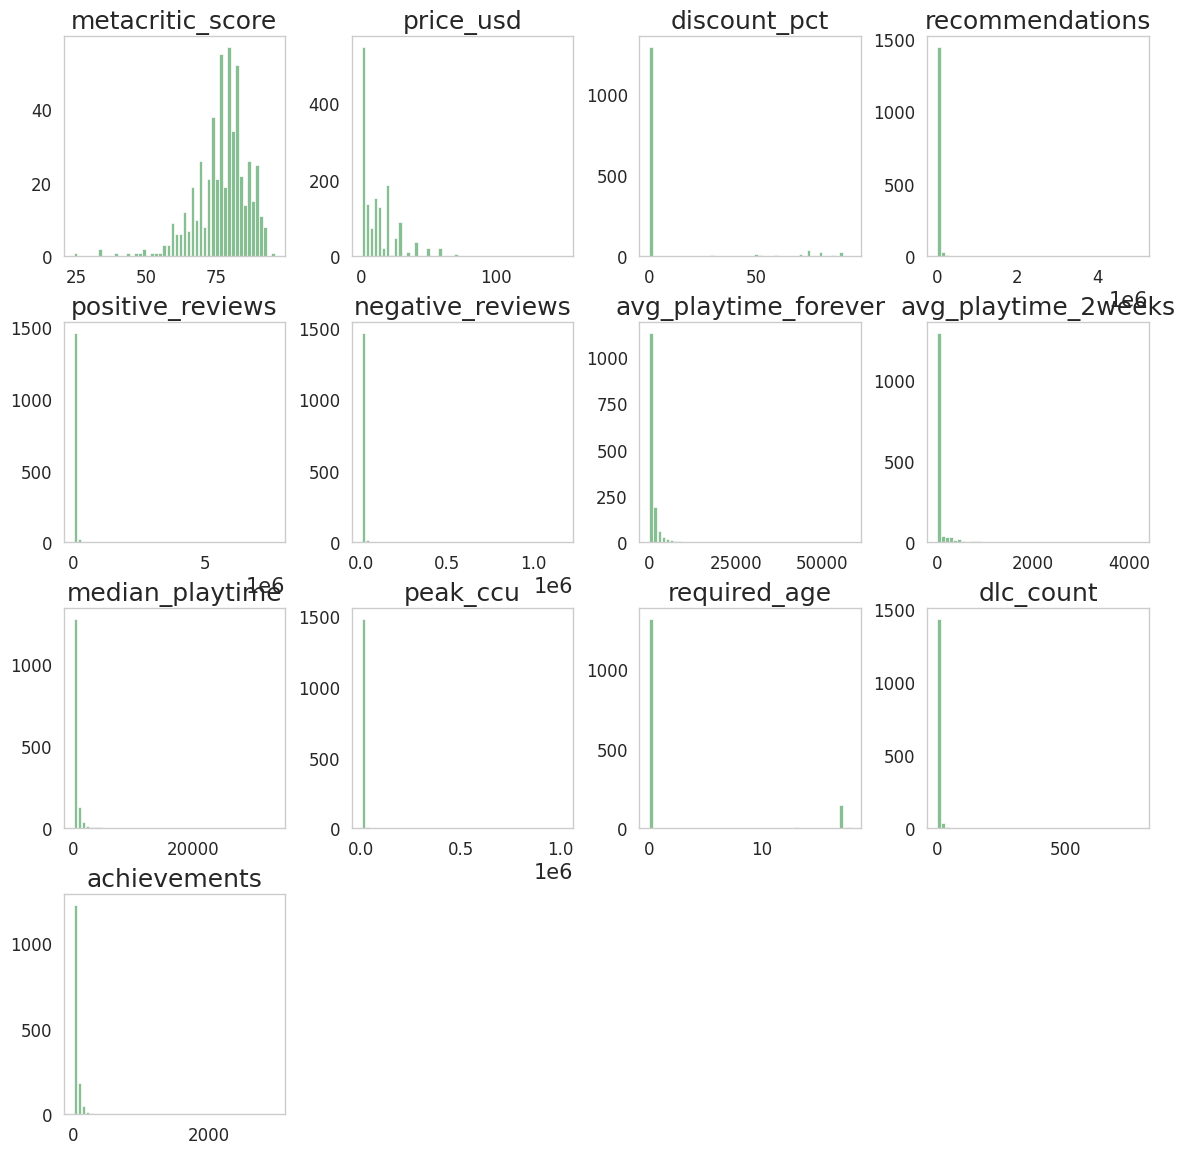

In [314]:
ax = df.hist(bins=50, grid=False, figsize=(14,14), layout=(4,4), color='#86bf91', 
                      zorder=2, rwidth=0.9, xlabelsize=12, ylabelsize=12)

## Обработаем строки с нетипичными значениями

In [315]:
print(len(df))
df_clean_1 = df.dropna(subset=[TARGET]).reset_index(drop=True)
print(len(df))

# работаем на копии исходного датафрейма
df_clean_2 = df_clean_1.copy()

# разделяем строку по разделителю ' .. ' на два отдельных столбца
owners_split = df_clean_2['estimated_owners'].str.split(' .. ', expand=True)

# удаляем запятые из чисел и конвертируем во float 
# (тип float используется, чтобы корректно сохранить NaN-значения, если они есть в строках)
df_clean_2['owners_lower'] = owners_split[0].str.replace(',', '', regex=False).astype(float)
df_clean_2['owners_upper'] = owners_split[1].str.replace(',', '', regex=False).astype(float)

# удаляем исходную текстовую колонку, так как она больше не нужна
df_clean_2 = df_clean_2.drop(columns=['estimated_owners'])

# переводим строки с датами в формат datetime
df_clean_2['release_date_dt'] = pd.to_datetime(df_clean_2['release_date'], errors='coerce')
df_clean_2 = df_clean_2.dropna(subset=['release_date_dt']).reset_index(drop=True)

# извлекаем полезные числовые признаки:
df_clean_2['release_year'] = df_clean_2['release_date_dt'].dt.year
df_clean_2['days_since_release'] = (df_clean_2['release_date_dt'].max() - df_clean_2['release_date_dt']).dt.days

df_clean_2 = df_clean_2.drop(columns=['release_date', 'release_date_dt'], errors='ignore')

UPDATED_FEATURES = [f for f in FEATURES if f != 'estimated_owners' and f != 'release_date' and f != 'release_date_dt'] + \
                   ['owners_lower', 'owners_upper', 'release_year', 'days_since_release']

cols_to_filter = ['price_usd', 'avg_playtime_forever', 'median_playtime', 'negative_reviews', 'positive_reviews']
for col in cols_to_filter:
    # приводим колонку к числовому типу (нечисловые значения станут NaN)
    df_clean_2[col] = pd.to_numeric(df_clean_2[col], errors='coerce')

    Q1 = df_clean_2[col].quantile(0.25)
    Q3 = df_clean_2[col].quantile(0.75)
    IQR = Q3 - Q1

    # Считаем границы
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Фильтруем датасет и сбрасываем индекс
    df_clean_2 = df_clean_2[(df_clean_2[col] >= lower_bound) & (df_clean_2[col] <= upper_bound)].reset_index(drop=True)

# Все значения выше границы станут равны ей
df_clean_2['discount_pct'] = df_clean_2['discount_pct'].clip(upper=100)

# уменьшаем влияние тяжёлого хвоста
heavy_tailed_cols = ['peak_ccu']
for col in heavy_tailed_cols:
    df_clean_2[f'{col}_log'] = np.log1p(df_clean_2[col])
  
df_clean_2 = df_clean_2.dropna(subset=UPDATED_FEATURES).reset_index(drop=True)

print(len(df_clean_2))

1495
1495
364


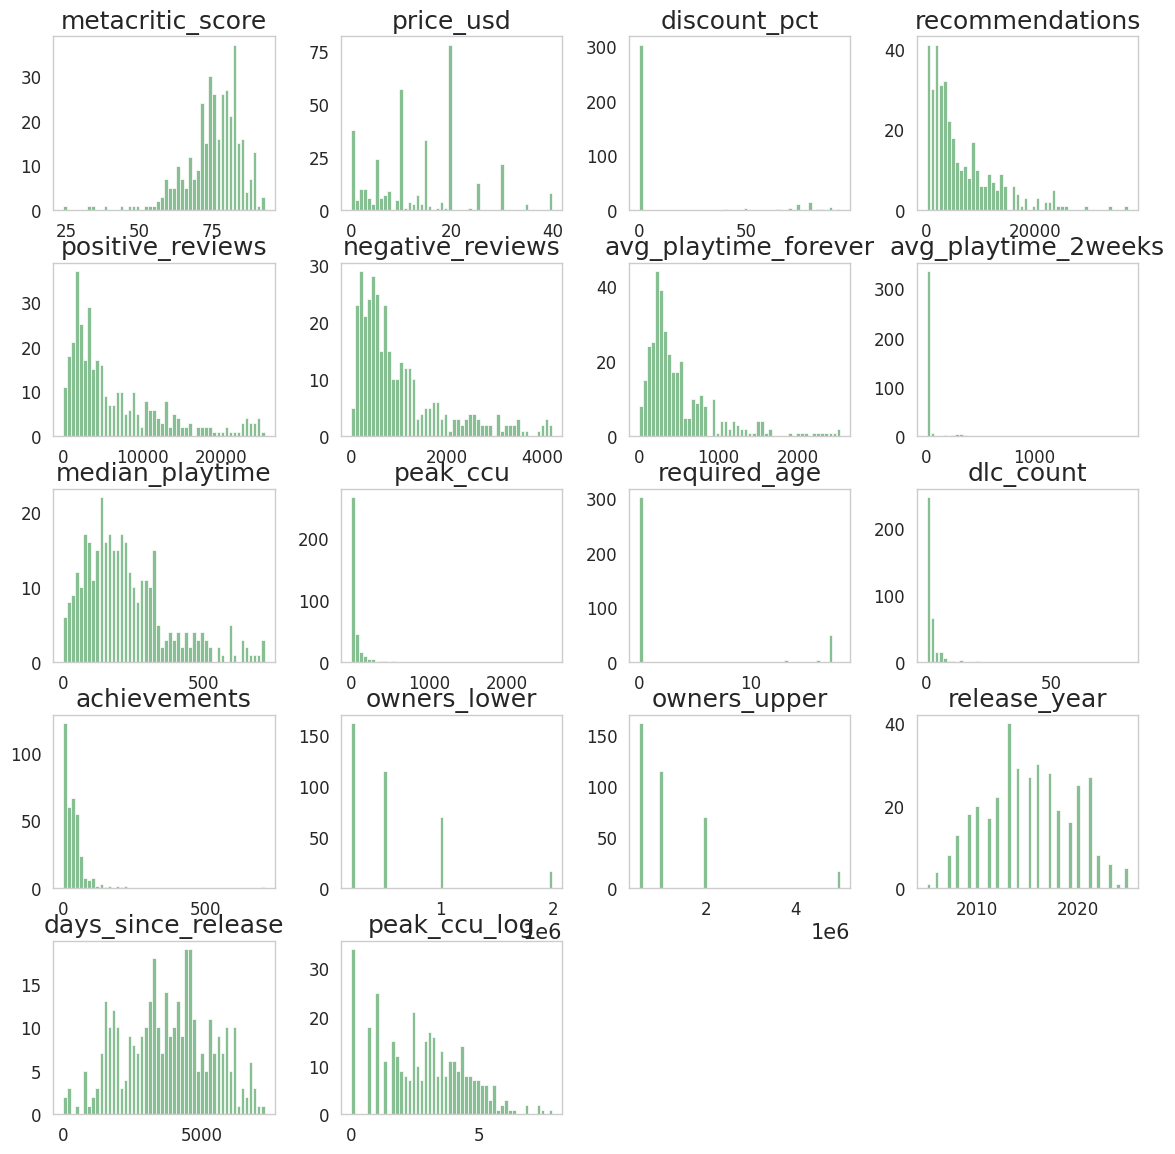

In [316]:
ax = df_clean_2.hist(bins=50, grid=False, figsize=(14,14), layout=(5,4), color='#86bf91', 
                      zorder=2, rwidth=0.9, xlabelsize=12, ylabelsize=12)

## Сделаем преобразование данных

In [317]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df_transformed = df_clean_2.copy()

x_train = df_transformed[UPDATED_FEATURES].copy()
y_train = df_transformed[TARGET].copy()

x_scaler = MinMaxScaler()
x_scaler.fit(x_train)
x_train = x_scaler.transform(x_train)

all_scaler = MinMaxScaler()
all_scaler.fit(df_transformed)
all_scaled = all_scaler.transform(df_transformed)
print(df_transformed.shape, all_scaled.shape)

(364, 23) (364, 23)


### Feature Importance 1. Градиентный бустинг

In [318]:
from sklearn import ensemble

params = {
    "n_estimators": 300,
    "max_depth": 4,
    "min_samples_split": 10,
    "learning_rate": 0.01,
    "verbose": 0,
}
model_base_full = ensemble.GradientBoostingRegressor(**params)
model_base_full.fit(x_train, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

In [319]:
N_FEATURES = 9

[ 9 13  8  7 10 20 12 16  1]


<Axes: xlabel='Vals', ylabel='Name'>

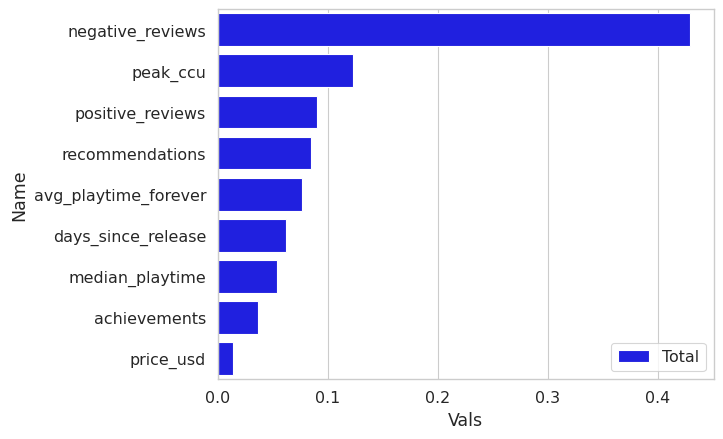

In [320]:
import copy
base_feature_importance = copy.deepcopy(model_base_full.feature_importances_)
base_feature_importance_sorted_idx = np.argsort(base_feature_importance)[::-1]
base_feature_importance_sorted_idx = base_feature_importance_sorted_idx[0:N_FEATURES]
print(base_feature_importance_sorted_idx)

boosting_names = [UPDATED_FEATURES[i] for i in base_feature_importance_sorted_idx]
vals = base_feature_importance[base_feature_importance_sorted_idx]
fimps = pd.DataFrame(data={'Name': boosting_names, 'Vals':vals})

sns.set_context("paper", font_scale=1.3)
sns.barplot(x="Vals", y="Name", data=fimps, label="Total", color="b", )


### Feature Importance 2. Муравьиная колония (UFSACO)

In [331]:
# Малое число
EPS = 1e-6
# Первоначальное число признаков
N_START_FEATURES = all_scaled.shape[1]
print(N_START_FEATURES)
# Итоговое число признаков
N_END_FEATURES = 9
# Максимально число циклов 
NC_MAX = 35
# Число шагов внутри цикла 
N_STEPS = 2
# Начальное количество феромона
INIT_PHEROMONE = 0.3
# коэффициент испарения
RO = 0.5
# Вероятность выполнения шага применения (exploitation)
EXPLOITATION_PROB = 0.6
# Параметры относительной важности некоррелированности выбираемых фичей и коррелированности с таргетом относительно желательности фичи.
ALPHA = 0.5 
BETA = 2.0
# Число агентов 
N_ANTS = 6

23


In [332]:
sim = {}
def set_sim(i, j):
    a = all_scaled[:, i]
    b = all_scaled[:, j]
    res = np.dot(np.asarray(a), np.asarray(b)) / (np.linalg.norm(a) * np.linalg.norm(b))    
    sim[(min(i, j), max(i, j))] = np.abs(res)
    return res

def get_sim(i, j):
    (i, j) = (min(i, j), max(i, j))
    if (i, j) not in sim.keys():
        set_sim(i, j)
    return sim[(i, j)]
  




Цикл по этапам перераспределения: count = 0;NC_MAX=3:

    ants_pos = np.random.choice(N_START_FEATURES, size=N_ANTS, p=tau/sum(tau)) # tau - ферромон

    nodes_visited = {(k, i): set()}

    Цикл по длине пути муравья от старта: iter = 0;4:

        Цикл по номерам муравьёв: k=0;5:

            i = ants_pos[k] # номер фичи i, последней для k-го муравья   

            node_score = [tau[j]/cos(i-ая, j-ая фичи) for j in unvisited]

              # подобрать номер фичи jj из unvisited по EXPLORATION / EXPLOITATION 
              (Random on distr / ArgMax{node_score}) j = unvisited[jj]

            ants_pos[k] = j     

            nodes_visited[(k, i)].add(j)

    Пересчёт ферромона: tau = (1 - RO) * tau + (visits / total_visits)  # посещения только с текущего этапа 
        

In [333]:
def UFSACO(verbose=True):
    # Инициируем начальным значением феромона в каждом узле
    tau = INIT_PHEROMONE * np.ones((N_START_FEATURES))

    #np.random.seed(1234)
    # Внешний цикл - число эпох
    for count in range(NC_MAX):
        # случайно размещаем муравьёв по узлам с вероятностью, пропорциональной феромону
        ants_pos = np.random.choice(N_START_FEATURES, size=N_ANTS, p=tau/sum(tau))
        # print(ants_pos)

        # Очищаем счётчик посещений узлов для каждого узла
        visits = np.zeros((N_START_FEATURES))

        # Очищаем множество посещённых узлов каждым k-ым агентом из каждого i-ого узла 
        nodes_visited = {(k, i): set() for k in range(N_ANTS) for i in range(N_START_FEATURES)}

        # внутренний цикл - длина пути, который проходят все муравьи
        for iter in range(N_STEPS):
            # k - номер текущего муравья
            # самый внутренний - шаг одного муравья
            for k in range(N_ANTS):
                # на каком узле i-ом узле находится k-ый муравей
                i = ants_pos[k]
                # print(i)
                # множество посещённых узлов
                visited = nodes_visited[(k, i)]
                # print(visited)
                # множество непосещённых узлов
                unvisited = list((set(range(N_START_FEATURES)) - visited) - {i})
                # print(unvisited)

                # массив "желательности" узла

                # 1) UFSACO: без учёта таргета
                #print([get_sim(i, j) for j in unvisited])
                node_score = [tau[j] / np.power(get_sim(i, j), ALPHA) for j in unvisited]
                #print(node_score)

                # какой шаг выполняем - exploration или exploitation?
                q = np.random.uniform()
                # print(q)
                if q <= EXPLOITATION_PROB:
                    # EXPLOITATION
                    if verbose:
                        print("EXPLOITATION")
                    # переходим в узел с максомальной желательностью
                    jj = np.argmax(node_score)
                else:
                    # EXPLORATION
                    if verbose:
                        print("EXPLORATION")
                    # чтобы никогда не делить на чистый ноль, если get_sim == 0
                    node_score = [tau[j] / (np.power(get_sim(i, j), ALPHA) + EPS) for j in unvisited]
                    
                    # Превращаем в массив numpy для удобства работы
                    node_score = np.array(node_score)
                    
                    # На всякий случай убираем случайные NaN или Inf, если get_sim вернул что-то странное
                    node_score = np.nan_to_num(node_score, nan=0.0, posinf=0.0, neginf=0.0)
                    
                    sum_score = sum(node_score)
                    
                    # Проверяем, что сумма не равна нулю и не NaN
                    if sum_score == 0 or np.isnan(sum_score):
                        # Если выбирать не из чего (все по нулям), делаем выбор равновероятным
                        p = np.ones(len(unvisited)) / len(unvisited)
                    else:
                        # Нормализуем вероятности
                        p = node_score / sum_score
                        
                        # Небольшая корректировка ошибок округления float (чтобы сумма строго равнялась 1.0)
                        p = p / np.sum(p)
                    
                    # Теперь choice никогда не упадет
                    jj = np.random.choice(len(unvisited), size=1, p=p)[0]
                # получаем номер следущего узла j для k: i -> j
                j = unvisited[jj]
                # перемещаем k-ого муравья в j-ый узел
                ants_pos[k] = j
                # добавляем информацию о перемещении
                nodes_visited[(k, i)].add(j)
                # увеличиваем счётчик посещения j-ого узла
                visits[j] += 1
                if verbose:
                    print(f"count={count}, iter={iter}, k={k}, i={i}, j={j}")
        # пересчитываем количество феромона
        total_visits = sum(visits)
        tau = (1 - RO) * tau + (visits / total_visits)
    return tau

### Запустим алгоритм 5 раз и оценим устойчивость при выбранных значениях гиперпараметров

In [352]:
all_input_names = [TARGET,] + UPDATED_FEATURES

for a in range(5): 
    features_UFSACO = np.array(UFSACO(verbose=False).argsort()[::-1][0:N_END_FEATURES])
    names = [all_input_names[i] for i in features_UFSACO]
    print(names)
    

['coming_soon', 'metacritic_score', 'is_free', 'avg_playtime_2weeks', 'discount_pct', 'owners_lower', 'owners_upper', 'median_playtime', 'positive_reviews']
['coming_soon', 'metacritic_score', 'dlc_count', 'owners_upper', 'discount_pct', 'is_free', 'platforms_win', 'peak_ccu', 'avg_playtime_forever']
['coming_soon', 'metacritic_score', 'platforms_mac', 'is_free', 'days_since_release', 'recommendations', 'discount_pct', 'platforms_linux', 'median_playtime']
['coming_soon', 'metacritic_score', 'avg_playtime_2weeks', 'days_since_release', 'is_free', 'release_year', 'achievements', 'dlc_count', 'discount_pct']
['coming_soon', 'metacritic_score', 'is_free', 'price_usd', 'platforms_win', 'avg_playtime_forever', 'platforms_mac', 'median_playtime', 'days_since_release']


### Посмотрим на итоговую схожесть признаков

In [353]:
all_sims = []
all_pairs = []
for i, name1 in enumerate(all_input_names):
    for j, name2 in enumerate(all_input_names):
        if j > i:
            #print(name1, name2, get_sim(i,j))
            all_sims.append(get_sim(i,j))
            all_pairs.append(name1+' + '+name2)
            
series = pd.Series(data=all_sims, index=all_pairs)
print(len(series))
display(series.sort_values(ascending=False)[:10])
display(series.sort_values(ascending=True)[:10])   
            


231


owners_lower + owners_upper               0.988131
recommendations + positive_reviews        0.962582
metacritic_score + release_year           0.905879
metacritic_score + days_since_release     0.901407
median_playtime + release_year            0.844152
avg_playtime_forever + median_playtime    0.839042
price_usd + release_year                  0.821124
metacritic_score + median_playtime        0.817181
platforms_mac + platforms_linux           0.810828
metacritic_score + price_usd              0.808515
dtype: float64

price_usd + is_free                      0.000000
is_free + discount_pct                   0.000000
is_free + avg_playtime_2weeks            0.000000
is_free + recommendations                0.025001
avg_playtime_2weeks + dlc_count          0.043456
peak_ccu + required_age                  0.065123
is_free + peak_ccu                       0.066146
is_free + required_age                   0.067893
is_free + median_playtime                0.094526
platforms_linux + avg_playtime_2weeks    0.094653
dtype: float64

### Результаты от бустинга и муравьиной колонии

In [354]:
# 1. Находим пересечение (общие признаки)
intersection = set(names) & set(boosting_names)

boost_sorted = sorted(list(boosting_names))
aco_sorted = sorted(list(names))
max_len = max(len(boost_sorted), len(aco_sorted))

print("=" * 65)
print(f"{'Gradient Boosting':<30} | {'UFSACO':<30}")
print("=" * 65)

for i in range(max_len):
    b_feat = boost_sorted[i] if i < len(boost_sorted) else ""
    a_feat = aco_sorted[i] if i < len(aco_sorted) else ""
    
    b_marker = "*  " if b_feat in intersection else "   "
    a_marker = "*  " if a_feat in intersection else "   "
    
    print(f"{b_marker}{b_feat:<27} | {a_marker}{a_feat:<27}")

print("=" * 65)
print(f"Общих признаков: {len(intersection)}")
if intersection:
    print(f"Пересечение: {list(intersection)}")
print("=" * 65)

Gradient Boosting              | UFSACO                        
   achievements                | *  avg_playtime_forever       
*  avg_playtime_forever        |    coming_soon                
*  days_since_release          | *  days_since_release         
*  median_playtime             |    is_free                    
   negative_reviews            | *  median_playtime            
   peak_ccu                    |    metacritic_score           
   positive_reviews            |    platforms_mac              
*  price_usd                   |    platforms_win              
   recommendations             | *  price_usd                  
Общих признаков: 4
Пересечение: ['median_playtime', 'price_usd', 'days_since_release', 'avg_playtime_forever']
